In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('youtube_hktw_cleaned.csv',keep_default_na=False)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24086 entries, 0 to 24085
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   video_id                         24086 non-null  object 
 1   video_published_at               24086 non-null  object 
 2   video_trending__date             24086 non-null  object 
 3   video_trending_country           24086 non-null  int64  
 4   channel_id                       24086 non-null  object 
 5   video_title                      24086 non-null  object 
 6   video_description                24086 non-null  object 
 7   video_default_thumbnail          24086 non-null  object 
 8   video_category_id                24086 non-null  int64  
 9   video_tags                       24086 non-null  object 
 10  video_duration                   24086 non-null  object 
 11  video_dimension                  24086 non-null  object 
 12  video_definition  

In [5]:
features = [
    'video_category_id', 'video_trending_country', 'publish_hour',
    'publish_day_of_week', 'title_length', 'tag_count',
    'channel_subscriber_count', 'video_definition',
    'video_licensed_content', 'channel_have_hidden_subscribers',
    'is_shorts'
]

X = df[features]
y = df['reach_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.join(y_train).to_csv('youtube_train_v1.csv', index=False)
X_test.join(y_test).to_csv('youtube_test_v1.csv', index=False)

print(f"Train: {len(X_train)},Test: {len(X_test)}")

Train: 19268,Test: 4818


In [8]:
#未加新features
train_df = pd.read_csv('/content/youtube_train_v1.csv')
test_df = pd.read_csv('/content/youtube_test_v1.csv')

X = train_df.drop('reach_level',axis = 1)
y = train_df['reach_level']

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators= 1000,
    learning_rate = 0.05,
    max_depth = 6,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose = 100
)

X_test = test_df.drop('reach_level', axis=1)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("Report：")
print(classification_report(y_val, val_preds_labels))

[0]	validation_0-rmse:0.57596
[100]	validation_0-rmse:0.39425
[200]	validation_0-rmse:0.39202
[273]	validation_0-rmse:0.39211
Report：
              precision    recall  f1-score   support

           1       0.93      0.94      0.94      3165
           2       0.40      0.51      0.45       386
           3       0.87      0.44      0.58       303

    accuracy                           0.86      3854
   macro avg       0.73      0.63      0.65      3854
weighted avg       0.87      0.86      0.86      3854



[0]	validation_0-mlogloss:1.07502
[100]	validation_0-mlogloss:0.50483
[200]	validation_0-mlogloss:0.46017
[300]	validation_0-mlogloss:0.44591
[400]	validation_0-mlogloss:0.43412
[500]	validation_0-mlogloss:0.42412
[600]	validation_0-mlogloss:0.41728
[700]	validation_0-mlogloss:0.41098
[800]	validation_0-mlogloss:0.40739
[900]	validation_0-mlogloss:0.40570
[1000]	validation_0-mlogloss:0.40523
[1004]	validation_0-mlogloss:0.40523

Report：
              precision    recall  f1-score   support

           1       0.95      0.90      0.92      3165
           2       0.37      0.55      0.44       386
           3       0.66      0.62      0.64       303

    accuracy                           0.84      3854
   macro avg       0.66      0.69      0.67      3854
weighted avg       0.87      0.84      0.85      3854



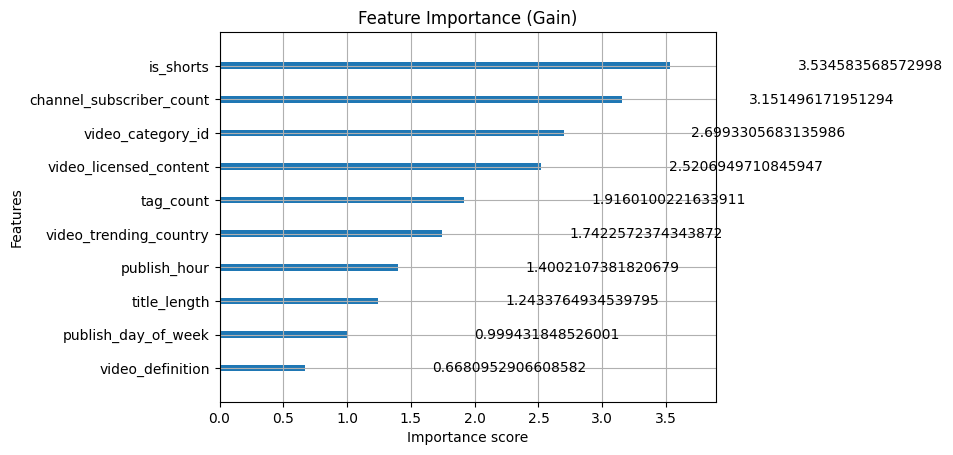

In [9]:
#改用classifier
X = train_df.drop('reach_level',axis = 1)
y = train_df['reach_level'] -1

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = xgb.XGBClassifier(
    n_estimators= 1500,
    learning_rate = 0.03,
    max_depth = 8,
    min_child_weight=1,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_val, y_val)],
    verbose=100
)

X_test = test_df.drop('reach_level', axis=1)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("\nReport：")
print(classification_report(y_val +1, val_preds_labels +1))

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.show()

In [10]:
#Feature排名榜
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
})

feature_importance_df['Importance_Percentage'] = (feature_importance_df['Importance_Score'] * 100).round(2)
feature_importance_df = feature_importance_df.sort_values(by='Importance_Percentage', ascending=False)

print("\nFeature排名榜")
print(feature_importance_df[['Feature', 'Importance_Percentage']])


Feature排名榜
                            Feature  Importance_Percentage
10                        is_shorts              17.780001
6          channel_subscriber_count              15.860000
0                 video_category_id              13.580000
8            video_licensed_content              12.680000
5                         tag_count               9.640000
1            video_trending_country               8.770000
2                      publish_hour               7.040000
4                      title_length               6.260000
3               publish_day_of_week               5.030000
7                  video_definition               3.360000
9   channel_have_hidden_subscribers               0.000000


[0]	validation_0-mlogloss:1.07502
[100]	validation_0-mlogloss:0.50481
[200]	validation_0-mlogloss:0.46027
[300]	validation_0-mlogloss:0.44494
[400]	validation_0-mlogloss:0.43180
[500]	validation_0-mlogloss:0.42069
[600]	validation_0-mlogloss:0.41547
[700]	validation_0-mlogloss:0.41045
[800]	validation_0-mlogloss:0.40685
[841]	validation_0-mlogloss:0.40689

Report:
              precision    recall  f1-score   support

           1       0.95      0.89      0.92      3165
           2       0.38      0.58      0.46       386
           3       0.66      0.63      0.64       303

    accuracy                           0.84      3854
   macro avg       0.66      0.70      0.68      3854
weighted avg       0.87      0.84      0.85      3854



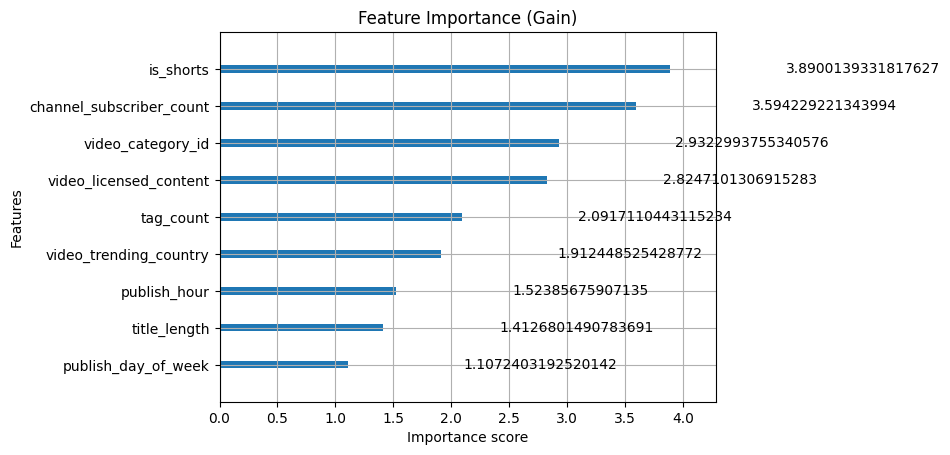

In [11]:
#嘗試drop走冇用既columns
drop_cols = ['reach_level', 'channel_have_hidden_subscribers', 'video_definition']

X = train_df.drop(columns=drop_cols)
y = train_df['reach_level'] -1

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = xgb.XGBClassifier(
    n_estimators= 1500,
    learning_rate = 0.03,
    max_depth = 8,
    min_child_weight=1,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_val, y_val)],
    verbose=100
)

X_test = test_df.drop(columns=drop_cols)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("\nReport:")
print(classification_report(y_val +1, val_preds_labels +1))

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.show()

[0]	validation_0-mlogloss:1.08159
[100]	validation_0-mlogloss:0.50922
[200]	validation_0-mlogloss:0.43373
[300]	validation_0-mlogloss:0.41363
[400]	validation_0-mlogloss:0.40566
[500]	validation_0-mlogloss:0.40158
[600]	validation_0-mlogloss:0.39921
[700]	validation_0-mlogloss:0.39815
[724]	validation_0-mlogloss:0.39857

Report:
              precision    recall  f1-score   support

           1       0.94      0.90      0.92      3165
           2       0.40      0.56      0.47       386
           3       0.68      0.61      0.64       303

    accuracy                           0.85      3854
   macro avg       0.67      0.69      0.68      3854
weighted avg       0.87      0.85      0.86      3854



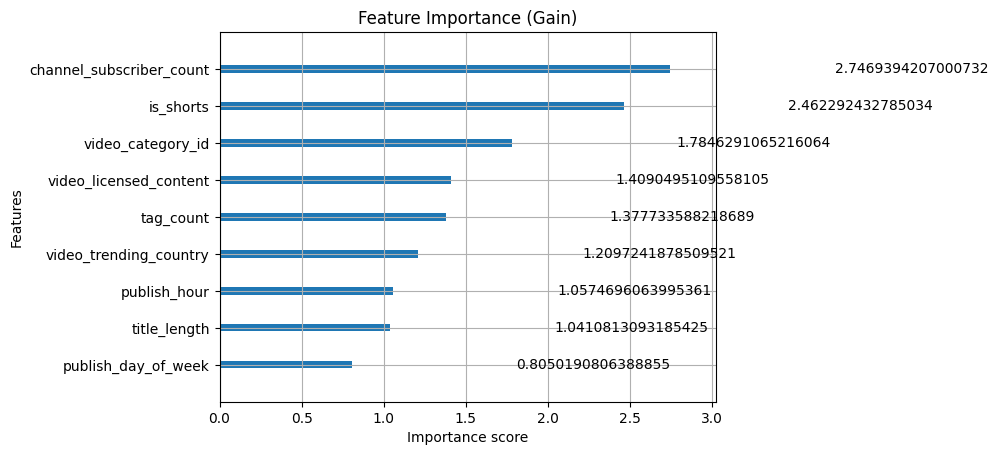

In [12]:
#再做hyperturning 試下將macro avg推高
X = train_df.drop(columns=drop_cols)
y = train_df['reach_level'] -1

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = xgb.XGBClassifier(
    n_estimators= 1500,
    learning_rate = 0.02,
    max_depth = 10,
    min_child_weight=0.1,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_val, y_val)],
    verbose=100
)

X_test = test_df.drop(columns=drop_cols)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("\nReport:")
print(classification_report(y_val +1, val_preds_labels +1))

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.show()

In [13]:
#再做多次features排行榜
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
})

feature_importance_df['Importance_Percentage'] = (feature_importance_df['Importance_Score'] * 100).round(2)
feature_importance_df = feature_importance_df.sort_values(by='Importance_Percentage', ascending=False)

print("\nfeature排行榜")
print(feature_importance_df[['Feature', 'Importance_Percentage']])


feature排行榜
                    Feature  Importance_Percentage
6  channel_subscriber_count              19.770000
8                 is_shorts              17.719999
0         video_category_id              12.840000
7    video_licensed_content              10.140000
5                 tag_count               9.920000
1    video_trending_country               8.710000
2              publish_hour               7.610000
4              title_length               7.490000
3       publish_day_of_week               5.790000


In [14]:
#嘗試加入新features將個分數推高D,final version既features
features = [
    'is_shorts', 'duration_seconds', 'channel_subscriber_count',
    'channel_view_count', 'channel_video_count', 'channel_age_days',
    'video_category_id', 'video_trending_country', 'channel_country_int',
    'video_licensed_content', 'publish_hour', 'publish_day_of_week',
    'title_length', 'tag_count'
]

X = df[features]
y = df['reach_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.join(y_train).to_csv('youtube_train_v2_final.csv', index=False)
X_test.join(y_test).to_csv('youtube_test_v2_final.csv', index=False)

print(f"Train:{len(X_train)},Test: {len(X_test)}")

Train:19268,Test: 4818


In [18]:
train_df = pd.read_csv('/content/youtube_train_v2_final.csv')
test_df = pd.read_csv('/content/youtube_test_v2_final.csv')

In [19]:
# 令model唔好太容易predect做level 1
X = train_df.drop('reach_level',axis = 1)
y = train_df['reach_level'] -1
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

weights = compute_sample_weight(class_weight='balanced', y=y_train)

[0]	validation_0-mlogloss:1.07656	validation_1-mlogloss:1.07894
[100]	validation_0-mlogloss:0.29736	validation_1-mlogloss:0.42778
[200]	validation_0-mlogloss:0.15293	validation_1-mlogloss:0.33759
[300]	validation_0-mlogloss:0.09996	validation_1-mlogloss:0.31514
[400]	validation_0-mlogloss:0.07568	validation_1-mlogloss:0.30833
[500]	validation_0-mlogloss:0.06290	validation_1-mlogloss:0.30772
[578]	validation_0-mlogloss:0.05432	validation_1-mlogloss:0.30763
Report：
              precision    recall  f1-score   support

           1       0.96      0.93      0.94      3165
           2       0.49      0.61      0.55       386
           3       0.73      0.70      0.72       303

    accuracy                           0.88      3854
   macro avg       0.73      0.75      0.74      3854
weighted avg       0.89      0.88      0.89      3854



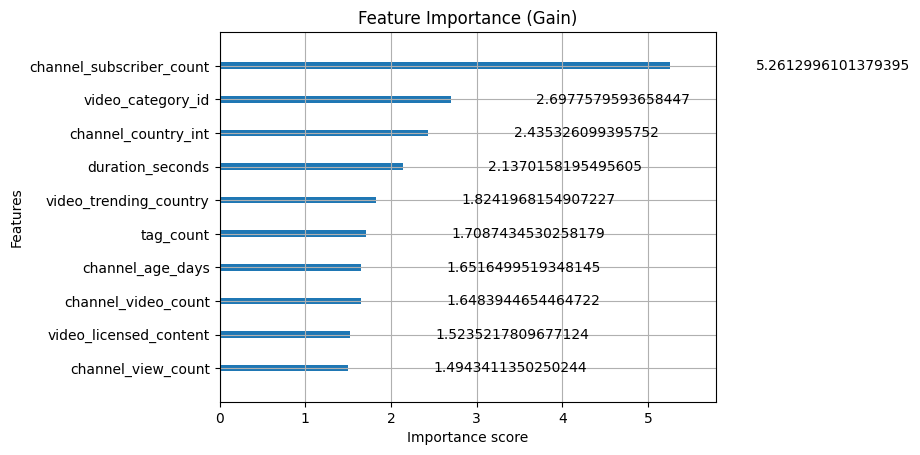

In [20]:
model = xgb.XGBClassifier(
    n_estimators= 1500,
    learning_rate = 0.02,
    max_depth = 10,
    min_child_weight=0.1,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

X_test = test_df.drop('reach_level',axis = 1)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("Report：")
print(classification_report(y_val +1, val_preds_labels +1))

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.show()

In [21]:
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
})

feature_importance_df['Importance_Percentage'] = (feature_importance_df['Importance_Score'] * 100).round(2)
feature_importance_df = feature_importance_df.sort_values(by='Importance_Percentage', ascending=False)

print("\nfeature排行榜")
print(feature_importance_df[['Feature', 'Importance_Percentage']])


feature排行榜
                     Feature  Importance_Percentage
2   channel_subscriber_count                  19.85
6          video_category_id                  10.18
8        channel_country_int                   9.19
1           duration_seconds                   8.06
7     video_trending_country                   6.88
13                 tag_count                   6.45
5           channel_age_days                   6.23
4        channel_video_count                   6.22
9     video_licensed_content                   5.75
3         channel_view_count                   5.64
10              publish_hour                   5.53
12              title_length                   4.38
11       publish_day_of_week                   3.56
0                  is_shorts                   2.09


[0]	validation_0-mlogloss:1.06970	validation_1-mlogloss:1.07164
[100]	validation_0-mlogloss:0.30539	validation_1-mlogloss:0.41120
[200]	validation_0-mlogloss:0.19988	validation_1-mlogloss:0.34684
[300]	validation_0-mlogloss:0.16068	validation_1-mlogloss:0.32938
[400]	validation_0-mlogloss:0.13526	validation_1-mlogloss:0.32042
[500]	validation_0-mlogloss:0.11306	validation_1-mlogloss:0.31436
[600]	validation_0-mlogloss:0.09407	validation_1-mlogloss:0.31004
[700]	validation_0-mlogloss:0.07876	validation_1-mlogloss:0.30830
[800]	validation_0-mlogloss:0.06441	validation_1-mlogloss:0.30706
[827]	validation_0-mlogloss:0.06126	validation_1-mlogloss:0.30713

Report：
              precision    recall  f1-score   support

           1       0.96      0.93      0.94      3165
           2       0.48      0.61      0.54       386
           3       0.73      0.72      0.73       303

    accuracy                           0.88      3854
   macro avg       0.72      0.75      0.74      3854
weighte

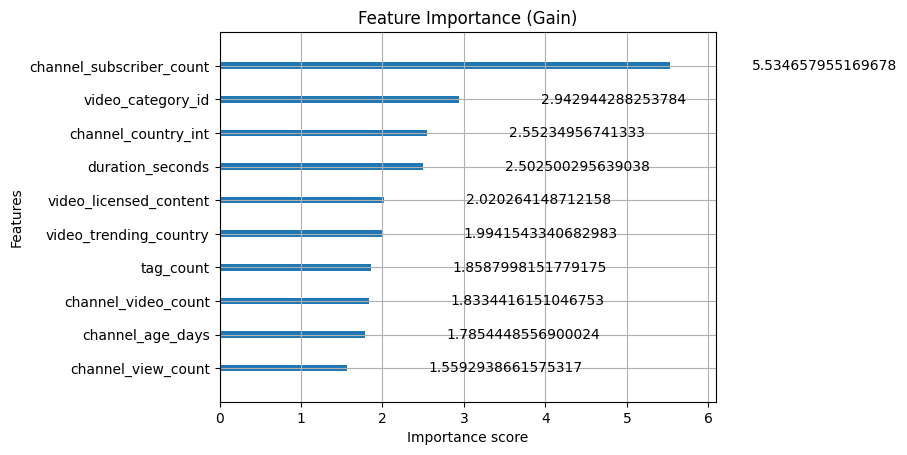

In [22]:
model = xgb.XGBClassifier(
    n_estimators= 1000,
    learning_rate = 0.03,
    max_depth = 8,
    min_child_weight=0.1,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

X_test = test_df.drop('reach_level',axis = 1)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("\nReport：")
print(classification_report(y_val +1, val_preds_labels +1))

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.show()

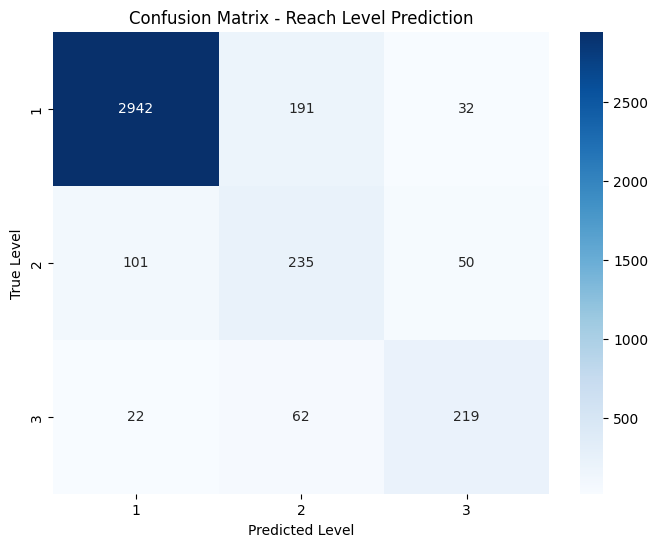

--- Confusion Matrix (Counts) ---
              Pred Lvl 1  Pred Lvl 2  Pred Lvl 3
Actual Lvl 1        2942         191          32
Actual Lvl 2         101         235          50
Actual Lvl 3          22          62         219

--- Confusion Matrix (Percentage %) ---
              Pred Lvl 1  Pred Lvl 2  Pred Lvl 3
Actual Lvl 1       92.95        6.03        1.01
Actual Lvl 2       26.17       60.88       12.95
Actual Lvl 3        7.26       20.46       72.28


In [27]:
cm = confusion_matrix(y_val + 1, val_preds + 1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])

plt.xlabel('Predicted Level')
plt.ylabel('True Level')
plt.title('Confusion Matrix - Reach Level Prediction')
plt.show()

cm_df = pd.DataFrame(
    cm,
    index=['Actual Lvl 1', 'Actual Lvl 2', 'Actual Lvl 3'],
    columns=['Pred Lvl 1', 'Pred Lvl 2', 'Pred Lvl 3']
)

print("--- Confusion Matrix (Counts) ---")
print(cm_df)
cm_percent = cm_df.div(cm_df.sum(axis=1), axis=0) * 100
print("\n--- Confusion Matrix (Percentage %) ---")
print(cm_percent.round(2))

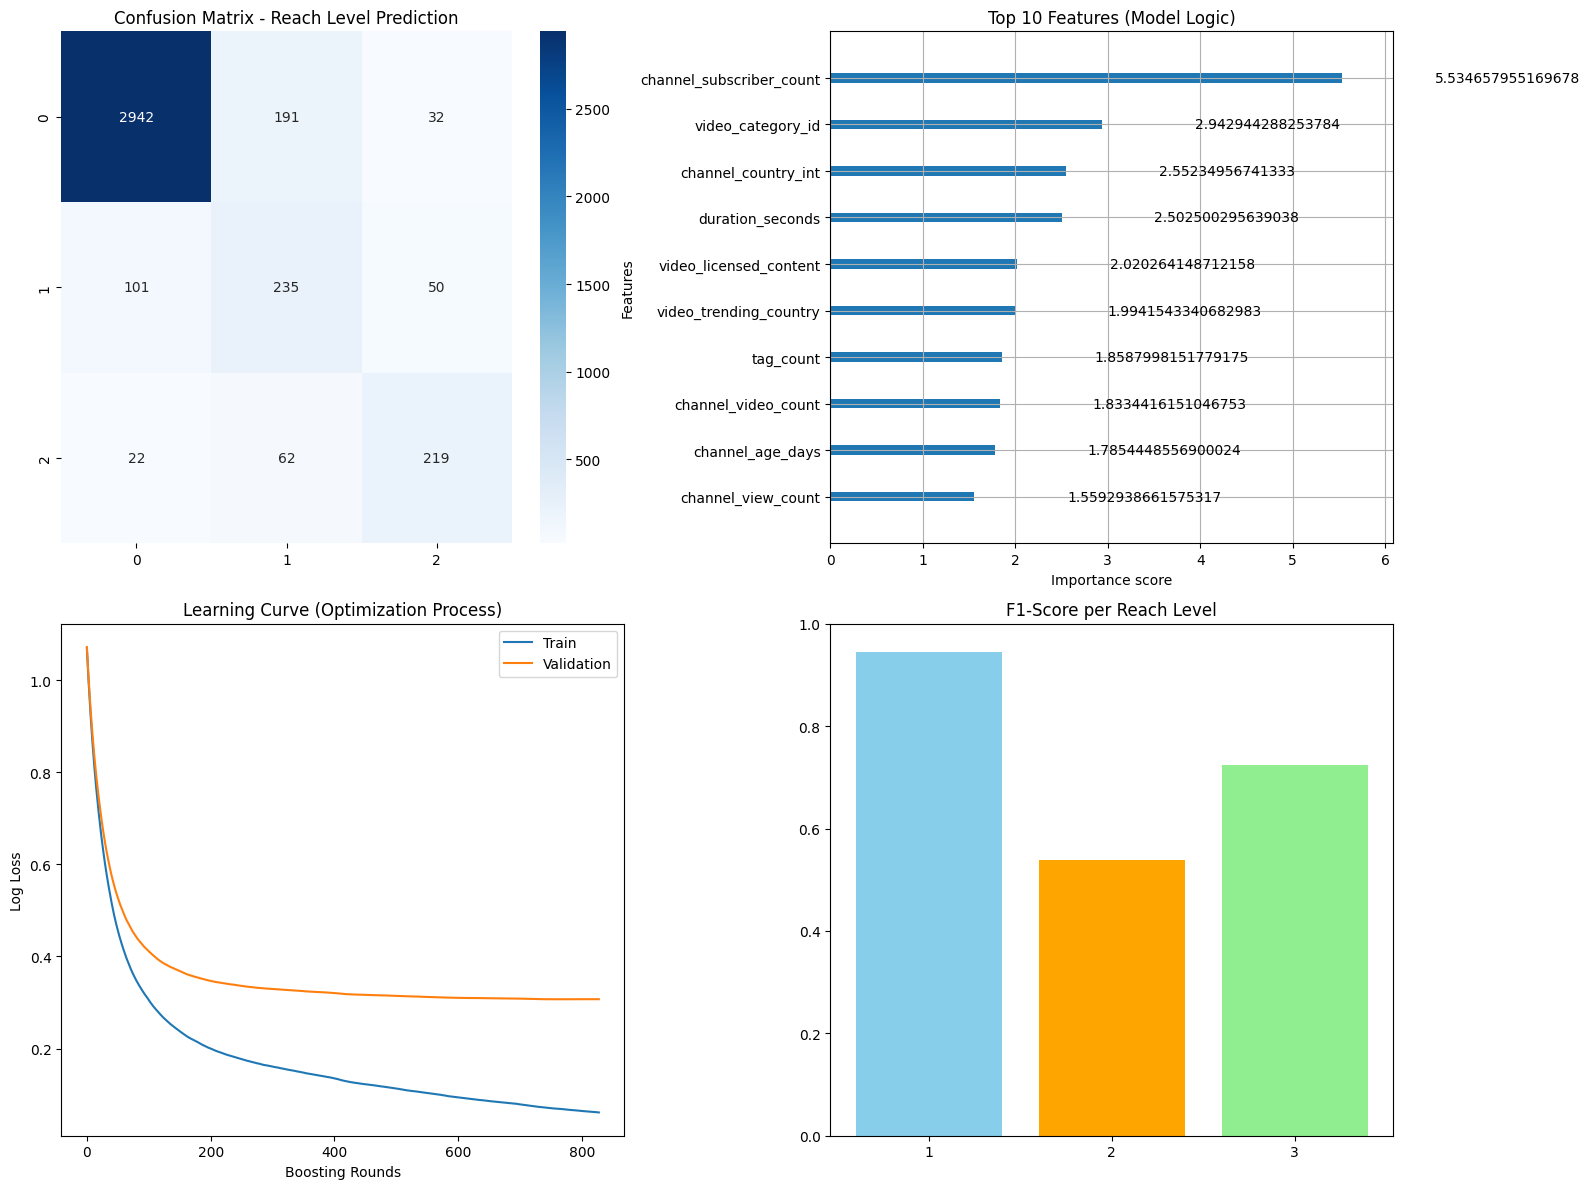

In [28]:
#2*2圖 放入PPT
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cm = confusion_matrix(y_val + 1, val_preds + 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix - Reach Level Prediction')

xgb.plot_importance(model, importance_type='gain', max_num_features=10, ax=axes[0,1])
axes[0,1].set_title('Top 10 Features (Model Logic)')

results = model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

axes[1, 0].plot(x_axis, results['validation_0']['mlogloss'], label='Train')

axes[1, 0].plot(x_axis, results['validation_1']['mlogloss'], label='Validation')

axes[1, 0].set_title('Learning Curve (Optimization Process)')
axes[1, 0].set_xlabel('Boosting Rounds')
axes[1, 0].set_ylabel('Log Loss')
axes[1, 0].legend()

report = classification_report(y_val + 1, val_preds + 1, output_dict=True)
levels = ['1', '2', '3']
f1_scores = [report[l]['f1-score'] for l in levels]
axes[1,1].bar(levels, f1_scores, color=['skyblue', 'orange', 'lightgreen'])
axes[1,1].set_title('F1-Score per Reach Level')
axes[1,1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [29]:
#查下個learning progress
results = model.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss = results['validation_1']['mlogloss']

print(f"Start: Train={train_loss[0]:.4f}, Val={val_loss[0]:.4f}")
print(f"Mid (100th): Train={train_loss[100]:.4f}, Val={val_loss[100]:.4f}")
print(f"End ({len(train_loss)}th): Train={train_loss[-1]:.4f}, Val={val_loss[-1]:.4f}")

Start: Train=1.0697, Val=1.0716
Mid (100th): Train=0.3054, Val=0.4112
End (828th): Train=0.0613, Val=0.3071
